In [1]:
# sys.path manipulation to include parent directory
import sys
from pathlib import Path

parent_folder = str(Path.cwd().parent)
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

# Importing necessary libraries and modules
from typing import List
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.config import ApplicationConfig

# Import the custom visualization module
from src.data_plotter import DataPlotter

In [2]:
raw_df = pd.read_csv(ApplicationConfig().data_path)
display(raw_df.head())

,Cycle,Preset_1,Preset_2,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency,Fail
0,1,3,6,"44,2352","47,6573","46,4418","64,8203","66,4545","44,4832",False
1,2,2,4,"60,8072","63,1721","62,0060","80,7144","81,2464","60,2287",False
2,3,2,1,"79,0275","83,0322","82,6421","98,2544","98,7852","80,9935",False
3,4,2,3,"79,7162","100,5086","122,3623","121,3634","118,6525","80,3156",False
4,5,2,5,"39,9891","51,7648","42,5143","61,0379","50,7165","64,2452",False


# 1. Dataset overview

Before diving into data analysis, it is important to understand and document the dataset’s variables. This step supports a clearer understanding of the problem and aids in defining the data schema when working with databases. Additionally, it guides the exploratory analysis by clarifying the meaning and interpretation of each variable.

Briefly, the dataset represents the monitoring of a Floating Production Storage and Offloading (FPSO) equipment unit across a sequence of operational cycles, with the goal of identifying and predicting equipment failures. It includes setup configurations, sensor readings such as temperature, pressure, and frequency, as well as a target variable indicating whether the equipment was in a failure state.

| Variable          | Type          | Data Type |Interpretation                                                                  |
| ----------------- | ------------- | --------- |------------------------------------------------------------------------------- |
| Cycle             | Temporal      | Numeric (int) |Represents the passage of time in operational cycles |
| Preset\_1         | Setup | Categorical (int) | Operational configuration parameter of the equipment                      |
| Preset\_2         | Setup | Categorical (int) |Operational configuration parameter of the equipment                                                         |
| Temperature       | Sensor        | Numeric (float) |Temperature measured in a given operation cycle                        |
| Vibrations\_X/Y/Z | Sensor        | Numeric (float) |Vibration measurements along the three spatial axes in a given operation cycle                            |
| Frequency         | Sensor        | Numeric (float) |Frequency measured in a given operation cycle                             |
| Fail              | Target        | Binary (bool) |Indicates whether the equipment is in a failure state (True) or normal (False)         |


# 2. Data Cleaning

Inspecting the raw dataset, it is possible to verify that the columns data types are not properly defined.

In [3]:
# Displaying the data types of the DataFrame
raw_df.dtypes

Cycle           int64
Preset_1        int64
Preset_2        int64
Temperature    object
Pressure       object
VibrationX     object
VibrationY     object
VibrationZ     object
Frequency      object
Fail             bool
dtype: object

## 2.1 Data Types

The float numeric columns are being interpreted as text because they use commas as decimal separators. To ensure proper numerical analysis in Python, these commas should be replaced with dots, and the columns should be converted to float data types.

In [4]:
# Function to convert object columns with commas to float
def parse_comma_decimal_series(series: pd.Series) -> pd.Series:
    return series.str.replace(',', '.').astype('float64')

# Function to get object columns with commas in their values
def find_comma_decimal_columns(df: pd.DataFrame) -> List[str]:
    """
    Returns a list of columns that contain commas in their values.
    """
    return [
        col for col in df.columns
        if df[col].dtype == 'object' and df[col].str.contains(',').any()
    ]

def df_convert_comma_decimals(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adjusts the data types of columns in the DataFrame.
    Converts object columns with commas to float.
    """
    obj_columns = find_comma_decimal_columns(df)
    for col in obj_columns:
        df[col] = parse_comma_decimal_series(df[col])
    return df

In [5]:
obj_columns = find_comma_decimal_columns(raw_df)
print(f"Columns with commas: {obj_columns}")

Columns with commas: ['Temperature', 'Pressure', 'VibrationX', 'VibrationY', 'VibrationZ', 'Frequency']


In [6]:
# Applying the conversion function to the DataFrame
df = df_convert_comma_decimals(raw_df)

In [7]:
# New data types of the DataFrame
print(df.dtypes)
display(df.head())

Cycle            int64
Preset_1         int64
Preset_2         int64
Temperature    float64
Pressure       float64
VibrationX     float64
VibrationY     float64
VibrationZ     float64
Frequency      float64
Fail              bool
dtype: object


,Cycle,Preset_1,Preset_2,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency,Fail
0,1,3,6,44.2352,47.6573,46.4418,64.8203,66.4545,44.4832,False
1,2,2,4,60.8072,63.1721,62.0060,80.7144,81.2464,60.2287,False
2,3,2,1,79.0275,83.0322,82.6421,98.2544,98.7852,80.9935,False
3,4,2,3,79.7162,100.5086,122.3623,121.3634,118.6525,80.3156,False
4,5,2,5,39.9891,51.7648,42.5143,61.0379,50.7165,64.2452,False


## 2.2 Null values and index

In [8]:
# Checking for null values in the DataFrame
df.isnull().sum()

Cycle          0
Preset_1       0
Preset_2       0
Temperature    0
Pressure       0
VibrationX     0
VibrationY     0
VibrationZ     0
Frequency      0
Fail           0
dtype: int64

No null values were found

In order to allow better handling of the time dimension on the dataset, the variable **Cycle** will be used as index.

In [9]:
# Define Cycle as the index
df.set_index('Cycle', inplace=True)

With all data cleaning pendencies solved, it is now possible to analyze the general statistics of the dataset.

In [10]:
# Export processed DataFrame to CSV
df.to_csv(ApplicationConfig().processed_data_path, index=True)

### Key Findings of Section 2: Data Cleaning

- **Data Types Correction:** Several numeric columns (e.g., Temperature, Pressure, VibrationX/Y/Z, Frequency) were initially read as text due to the use of commas as decimal separators. These were successfully converted to proper float types, enabling numerical analysis.
- **Null Values:** The dataset contains no missing values, ensuring completeness for analysis.
- **Indexing:** The 'Cycle' column was set as the DataFrame index, reflecting the temporal nature of the data and facilitating time-based operations.

# 3. Exploratory Data Analysis (EDA)

In this step, the main goal is to perform an initial examination of the dataset to understand the overall behavior of the variables. This may reveal general patterns, potential anomalies, and relationships between the equipment setup parameters and sensor measurements. It may also provide early insights into possible causes of equipment failures in the FPSO system.

## 3.1 Target variable analysis

### 3.1.1 Failure distribution

Fail
False    734
True      66
Name: count, dtype: int64


Fail
False    91.75
True      8.25
Name: proportion, dtype: float64


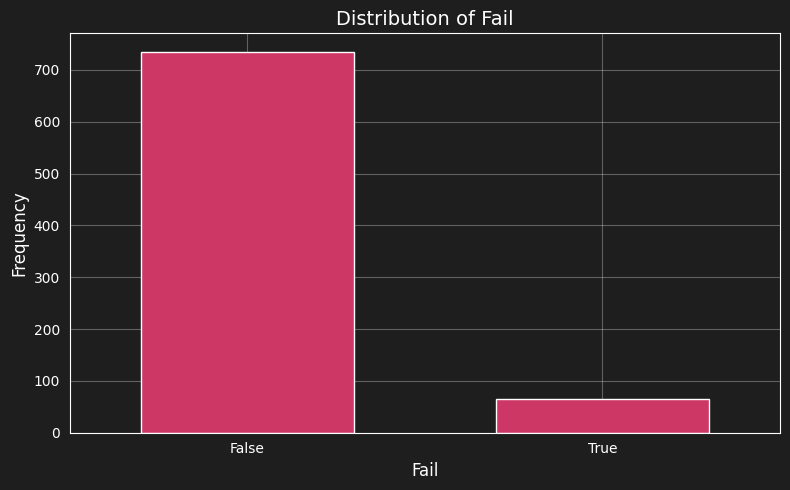

In [11]:
print(df['Fail'].value_counts())
print('\n')
print(df['Fail'].value_counts(normalize=True)*100)

fig = DataPlotter(figsize=(8,5)).plot_histogram(df, 'Fail')

According to the data, it is possible to affirm that the equipment was in a failure state for approximately 8.25% of the time or 66 operation cycles.

As expected, the target variable is imbalanced, since equipment failure is a relatively rare event. However, the failure state is precisely what needs to be predicted. For this reason, it is essential to understand the equipment’s behavior during failure, despite the smaller amount of available data.

### Key Findings of Section 3.1.1: Failure distribution

**Failure Events:** The equipment was in fail state for 66 of 800 operation cycles (~8.25% of total time).

### 3.1.2 Behavior of sensored variables during failures

First, the numeric variables, such as Temperature and Pressure, will be analyzed. This section aims to identify significant differences in their values between normal and failure states.

In [12]:
def create_stats_summary(df: pd.DataFrame, target_col: str = 'Fail_index', agg_funcs: List[str] = ['mean', 'max', 'median']) -> pd.DataFrame:
    """    Creates a summary DataFrame with specified aggregation functions for each sensor column.
    Args:
        df (pd.DataFrame): DataFrame containing the data.
        sensored_cols (List[str]): List of sensor columns to aggregate.
        target_col (str): Target column name for grouping.
        agg_funcs (List[str]): List of aggregation functions to apply.
    Returns:
        pd.DataFrame: DataFrame with aggregated statistics.
    """
    assert target_col in df.columns, f"Target column '{target_col}' not found in DataFrame."

    sensored_cols = df.select_dtypes(include=['float64']).columns.tolist()

    agg_dict = {col: agg_funcs for col in sensored_cols}
    agg_dict[target_col] = 'count'  # duration in operation cycles
    df = df.groupby(target_col).agg(agg_dict)
    
    return df


In [13]:
# Calculate statistics by failure state
stats_by_failure_state = create_stats_summary(df, target_col='Fail', agg_funcs=['mean', 'median', 'std']).drop(columns=['Fail'])
display(stats_by_failure_state)

Temperature                         Pressure                        \
             mean    median        std        mean     median        std   
Fail                                                                       
False   67.176883  64.81490  24.824880   75.632790   71.91120  30.561616   
True    92.469126  90.92895  21.683668  116.422541  110.61915  30.040055   

       VibrationX                       VibrationY                        \
             mean    median        std        mean     median        std   
Fail                                                                       
False   71.494801  66.35860  30.415829   68.318454   63.51685  29.010220   
True   100.167188  98.04375  28.109402  122.481161  122.11510  30.861776   

       VibrationZ                       Frequency                      
             mean    median        std       mean   median        std  
Fail                                                                   
False   68.796673  65.00595  25.678027  65.382993  62.6873  27.943439  
True   106.003211  99.66940  28.377487  99.812742  99.2127  22.960576

In [14]:
stats_by_failure_state = create_stats_summary(df, target_col='Fail', agg_funcs=['mean', 'median','max', 'min', 'std']).drop(columns=['Fail'])

All five sensor-based variables exhibit higher descriptive statistics during the failure state. The boxplots below visually illustrate this finding. Below, a series of boxplots represent this find visually.

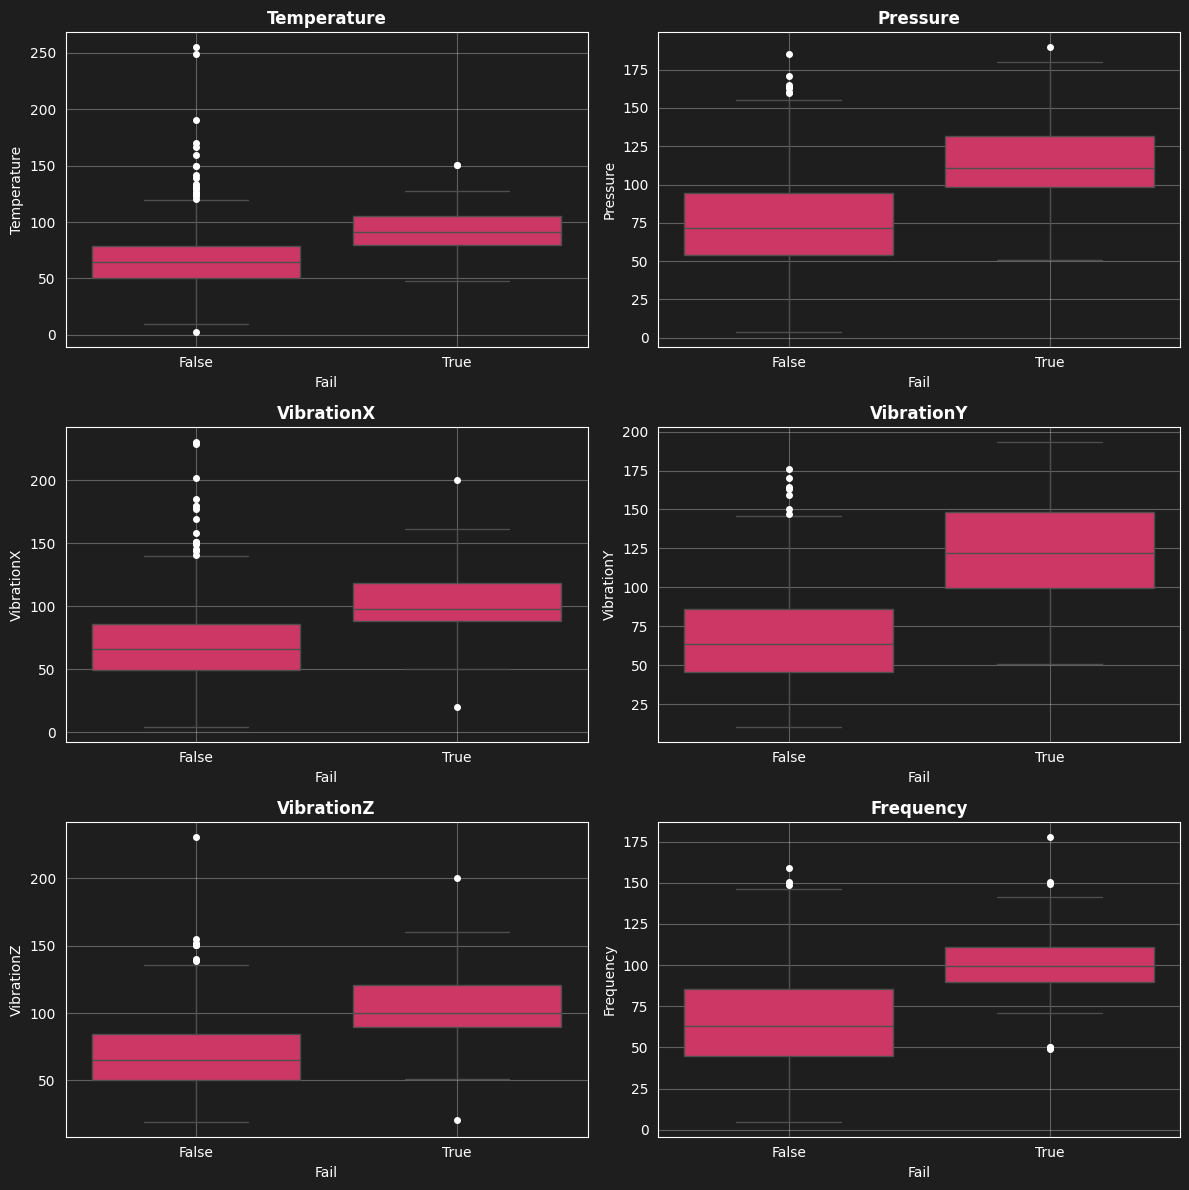

In [15]:
# Boxplot for each numeric column grouped by 'Fail'
# This will help visualize the distribution of each feature for both failure states
fig = DataPlotter().plot_multiple_boxplots(df, df.select_dtypes(float).columns.tolist(), 'Fail')

It becomes evident that all numeric variables tend to be higher when the equipment is in a failure state. This suggests that increasing values in these variables during operation cycles may be indicators of a possible future equipment failure. Additionally, the distributions of all variables show minimal overlap between normal and failure states, indicating strong predictive potential.

Among them, **VibrationY** and **Pressure** demonstrate the most significant differences between normal and failure conditions. This shows their potential importance in failure detection and suggests they may play a critical role in the feature importance analysis of the machine learning model to be developed.

One simple way to quantify these difference is calculating the mean differences of each variable in normal and failure state.

In [16]:
def mean_difference_by_target(df: pd.DataFrame, columns: List[str], target: str = 'Fail') -> pd.Series:
    """
    Calculates the mean difference for the specified columns between True and False states of the target variable.

    Args:
        df (pd.DataFrame): The dataframe containing the data.
        columns (list): List of column names to calculate mean difference for.
        target (str): The binary target column name.

    Returns:
        pd.Series: Mean difference (True - False) for each column.
    """
    assert target in df.columns, f"Target column '{target}' not found in DataFrame."
    assert all(col in df.columns for col in columns), "One or more specified columns not found in DataFrame."
    
    means_true = df[df[target] == True][columns].mean()
    means_false = df[df[target] == False][columns].mean()

    return means_true - means_false

In [17]:
# Calculate mean differences for float columns by target and sort results
mean_difference_by_target(df, df.select_dtypes(float).columns.tolist(), 'Fail').sort_values(ascending=False)

VibrationY     54.162707
Pressure       40.789751
VibrationZ     37.206537
Frequency      34.429749
VibrationX     28.672387
Temperature    25.292243
dtype: float64

Once again, the data reveals a significant increase in sensored variables during equipment failures. The mean **VibrationY** is approximately 54 units higher and mean **Pressure** is 40 units higher when the equipment is in a failure state.

### Key Findings of Section 3.1.2: Behavior of sensored variables during failures

- **Sensor Elevation**: All five sensor variables exhibit consistently higher values during failure states.

- **Primary Failure Indicators**: **VibrationY** and **Pressure** show the most significant mean differences between normal and failure states:
  - **VibrationY**: ~54 units higher during failures
  - **Pressure**: ~40 units higher during failures
  - These variables demonstrate strong predictive potential for failure detection

- **Clear Distribution Separation**: Boxplot analysis reveals minimal overlap between normal and failure state distributions across all sensor variables, suggesting strong discriminative power for machine learning models.

- **Early Warning Potential**: The consistent elevation of sensor readings during failures suggests these variables can serve as reliable indicators for developing predictive maintenance strategies and early warning systems.

### 3.1.3 Distribution of setup parameters during failures

The setup variables Preset_1 and Preset_2 define how the equipment is configured during an operation cycle. Analyzing their relationship with failure occurrences is essential to identify configuration combinations that are more likely to result in failures.

Considering the entire dataset, both variables exhibit a well-balanced distribution across their available values. Preset_1 has three unique values, each used in approximately one-third of the operation cycles. Similarly, Preset_2 has eight possible values, all of which appear with roughly equal frequency throughout the data collection period.

In [18]:
# Preset_1 and Preset_2 distributions
print(df['Preset_1'].value_counts(normalize=True)*100)
print(df['Preset_2'].value_counts(normalize=True)*100)

Preset_1
2    35.125
1    33.000
3    31.875
Name: proportion, dtype: float64
Preset_2
7    13.625
6    12.625
2    12.625
3    12.625
5    12.500
8    12.500
1    11.875
4    11.625
Name: proportion, dtype: float64


The histograms below reinforces the above interpretation.

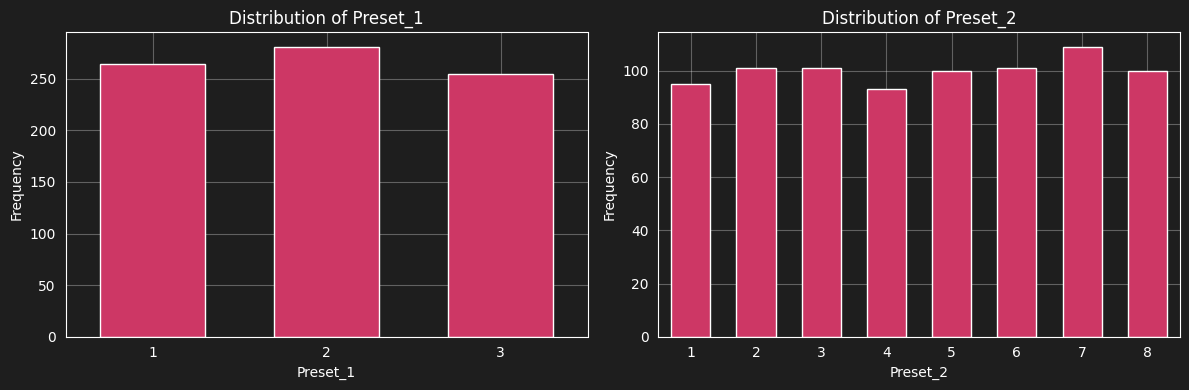

In [19]:
fig = DataPlotter().plot_multiple_histograms(df, ['Preset_1','Preset_2'])

On the other hand, when isolating the operation cycles with failure, certain setup parameters appear more frequently, such as values 1 and 2 for **Preset_1**, and 1 and 5 for **Preset_2**. Conversely, parameter 4 on **Preset_2** is relatively uncommon in failure events.

In [20]:
# Preset_1 and Preset_2 distributions considering only failure events
print(df.query('Fail == True')['Preset_1'].value_counts(normalize=True)*100)
print(df.query('Fail == True')['Preset_2'].value_counts(normalize=True)*100)

Preset_1
1    40.909091
2    31.818182
3    27.272727
Name: proportion, dtype: float64
Preset_2
5    18.181818
1    16.666667
2    13.636364
6    13.636364
7    13.636364
8    10.606061
3     9.090909
4     4.545455
Name: proportion, dtype: float64


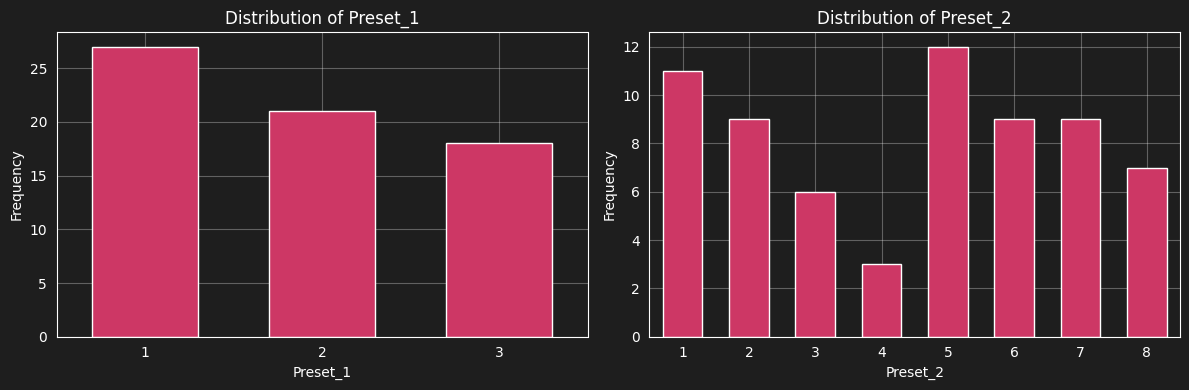

In [21]:
# Plotting histograms for Preset_1 and Preset_2 for failure events
fig = DataPlotter().plot_multiple_histograms(df.query("Fail == True"), ['Preset_1','Preset_2'])

Taking it a step further, specific combinations of **Preset_1** and **Preset_2** configurations may be correlated with failure events. To visualize this relationship, a heatmap can be used to show how the proportion of failures varies across different equipment setup combinations.

In [22]:
# Grouping by Preset_1 and calculating failure rate and number of cycles with failure
print(df.groupby(['Preset_1']).agg({'Fail': ['mean', 'sum']}).rename(columns={'mean': 'Failure Rate', 'sum': 'Cycles with Failure'}))
print('\n')
# Grouping by Preset_2 and calculating failure rate and number of cycles with failure
print(df.groupby(['Preset_2']).agg({'Fail': ['mean', 'sum']}).rename(columns={'mean': 'Failure Rate', 'sum': 'Cycles with Failure'}))

                 Fail                    
         Failure Rate Cycles with Failure
Preset_1                                 
1            0.102273                  27
2            0.074733                  21
3            0.070588                  18


                 Fail                    
         Failure Rate Cycles with Failure
Preset_2                                 
1            0.115789                  11
2            0.089109                   9
3            0.059406                   6
4            0.032258                   3
5            0.120000                  12
6            0.089109                   9
7            0.082569                   9
8            0.070000                   7


**Preset_1**
- Preset_1=1 has a higher failure rate (~10%) in comparison with the other two options.

**Preset_2**
- Preset_2=5 and Preset_2=1 appears to be risky, both with approximately 12% of failure rate.
- Preset_2=4 could be considered the safest setting, with only 3% of failure rate. 

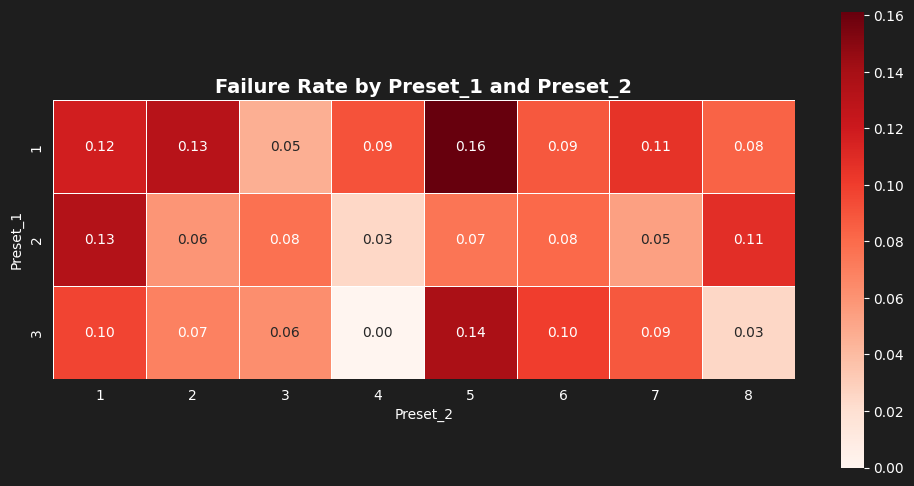

In [23]:
# Heatmap plotting failure rates by Preset_1 and Preset_2
fig = DataPlotter().plot_failure_rate_heatmap(df, row_var='Preset_1', col_var='Preset_2', target_var='Fail')

The heatmap reveals that certain equipment setups stand out with a noticeably higher occurrence of failures.

**Configurations with high failure rates**:
- Preset_1=1, Preset_2=5: Highest failure rate at 16%, almost double of the mean failure rate (8.25%).
- Preset_1=3, Preset_2=5: Second highest at 14%
- Preset_1=1, Preset_2=2: Third highest at 13%

**Configurations with low failure rates**:
- Preset_1=3, Preset_2=4: Zero failures (safest combination)
- Preset_1=2, Preset_2=4: Only 3% failure rate

Without specific knowledge of how the **Preset_1** and **Preset_2** parameters control equipment operation, it is difficult to recommend direct actions to minimize failure risk on the FPSO.

Nonetheless, based on the analyzed data, it is advisable to avoid configurations associated with high failure rates, especially during critical operations or peak production periods. As a safer alternative, combinations such as Preset_1 = 3 and Preset_2 = 4, which showed lower failure occurrences, could be prioritized when possible.

These critical equipment configurations should be closely monitored alongside sensor-based variables. The combination of high-risk setups with increases in variables such as vibration and pressure may serve as early warning signals of equipment failure.

### Key Findings of Section 3.1.3: Distribution of setup parameters during failures

- **Balanced Overall Distribution**: Both Preset_1 (3 values) and Preset_2 (8 values) show well-balanced distributions, with each configuration used approximately equally during operations.

- **High-Risk Individual Configurations**
  - **Preset_1=1**: Higher failure rate (~10%) compared to other Preset_1 options
  - **Preset_2=5** and **Preset_2=1**: Both show risky behavior with ~12% failure rates
  - **Preset_2=4**: Safest individual setting with only 3% failure rate

- **Critical Configuration Combinations**:
  - **Preset_1=1, Preset_2=5**: Highest failure rate at 16% (nearly double the overall 8.25% rate)
  - **Preset_1=3, Preset_2=5**: Second highest at 14%
  - **Preset_1=1, Preset_2=2**: Third highest at 13%

- **Safe Configuration Combinations**:
  - **Preset_1=3, Preset_2=4**: Zero failures recorded (safest combination)
  - **Preset_1=2, Preset_2=4**: Only 3% failure rate

- **Operational Recommendations**: Avoid high-risk configurations (especially Preset_1=1 with Preset_2=5) during critical operations.

- **Early Warning Integration**: High-risk equipment configurations could be monitored alongside sensor variables, as the combination of risky setups with elevated vibration and pressure readings may serve as compound early warning signals for equipment failure.

### 3.1.4 Failure event analysis

Another important aspect of this study is identifying distinct failure events and analyzing them in terms of their duration, causes, and associated variable behavior.

The first step is to find these events and categorize them on the dataset.

In [24]:
def find_failure_transitions(fail_series: pd.Series) -> dict:
    """
    Finds all failure transitions (starts and stops) in a boolean Series.

    Args:
        fail_series (pd.Series): A pandas Series of boolean values indicating failure state over time.

    Returns:
        dict: Dictionary containing:
            - 'starts': List of cycle ids where transitions from False to True occurred
            - 'stops': List of cycle ids where transitions from True to False occurred
            - 'events': List of tuples (start, stop) for each failure event
    """
    # Check if the input series is of boolean dtype
    if fail_series.dtype != bool:
        raise ValueError("Input series must be of boolean dtype.")
    
    # Use shift to 'move' rows one position down and verify previous state
    previous_state = fail_series.shift(1, fill_value=False)
    
    # Find transitions from False to True (failure starts)
    transition_starts = (~previous_state) & fail_series
    starts = list(transition_starts[transition_starts == True].index)
    
    # Find transitions from True to False (failure stops)
    transition_stops = previous_state & (~fail_series)
    stops = list(transition_stops[transition_stops == True].index)
    
    # If series ends with failure, add the last index as stop
    if len(starts) > len(stops):
        stops.append(fail_series.index[-1] + 1)  # Add one to include the last cycle as stop
    
    # Create failure events as (start, stop) tuples
    events = list(zip(starts, stops))
    
    return {
        'starts': starts,
        'stops': stops,
        'events': events
    }

In [25]:
# Finding failure transitions in the 'Fail' column
failure_events = find_failure_transitions(df['Fail'])

In [26]:
failure_events

{'starts': [13, 157, 163, 263, 270, 415, 538, 550, 700, 793],
 'stops': [14, 160, 166, 266, 272, 433, 547, 555, 714, np.int64(801)],
 'events': [(13, 14),
  (157, 160),
  (163, 166),
  (263, 266),
  (270, 272),
  (415, 433),
  (538, 547),
  (550, 555),
  (700, 714),
  (793, np.int64(801))]}

In [27]:
n = len(failure_events['events'])
failure_duration = df['Fail'].sum()

print(f"Total duration of failure state: {failure_duration} cycles")
print(f"Total number of failure events: {n}")
print(f"Mean failure state duration per occurence: {failure_duration / n} cycles")

Total duration of failure state: 66 cycles
Total number of failure events: 10
Mean failure state duration per occurence: 6.6 cycles


Therefore, the data reveals a total of **10 failure events** throughout the time series, resulting in **66 operation cycles** in the failure state.

These events are detailed below to provide a clearer understanding of each individual occurrence.

In [28]:
def label_failures(df: pd.DataFrame, failure_events: dict, fail_index_column: str = 'Fail_index') -> pd.DataFrame:
    """
    Labels the failure periods in the DataFrame with a unique index for each failure.

    Args:
        df (pd.DataFrame): DataFrame containing the failure data with 'Fail' column.
        failure_events (dict): Dictionary containing failure events with 'events' key.
        fail_index_column (str): Name of the column to store failure indices.

    Returns:
        pd.DataFrame: DataFrame with an additional 'Fail_index' column indicating failure periods.
    """
    # Initialize a new column for failure indices
    df[fail_index_column] = 0

    # Loop through each failure period and assign an index
    for i, event in enumerate(failure_events['events']):
        start, stop = event
        print(f"Failure {i+1} start at operation cycle: {start}")
        print(f"Failure {i+1} stop at operation cycle: {stop}")

        # Assigning a failure index to the DataFrame for each failure period
        mask = (df.index >= start) & (df.index < stop)
        df.loc[mask, 'Fail_index'] = i + 1

    return df

In [29]:
# Applying the function to label failures in the DataFrame
df = label_failures(df, failure_events=failure_events, fail_index_column='Fail_index')

Failure 1 start at operation cycle: 13
Failure 1 stop at operation cycle: 14
Failure 2 start at operation cycle: 157
Failure 2 stop at operation cycle: 160
Failure 3 start at operation cycle: 163
Failure 3 stop at operation cycle: 166
Failure 4 start at operation cycle: 263
Failure 4 stop at operation cycle: 266
Failure 5 start at operation cycle: 270
Failure 5 stop at operation cycle: 272
Failure 6 start at operation cycle: 415
Failure 6 stop at operation cycle: 433
Failure 7 start at operation cycle: 538
Failure 7 stop at operation cycle: 547
Failure 8 start at operation cycle: 550
Failure 8 stop at operation cycle: 555
Failure 9 start at operation cycle: 700
Failure 9 stop at operation cycle: 714
Failure 10 start at operation cycle: 793
Failure 10 stop at operation cycle: 801


In [30]:
# Sample of the DataFrame with failure indices indicating different failure events
df.head(15)

,Preset_1,Preset_2,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency,Fail,Fail_index
Cycle,,,,,,,,,,
1,3,6,44.2352,47.6573,46.4418,64.8203,66.4545,44.4832,False,0
2,2,4,60.8072,63.1721,62.0060,80.7144,81.2464,60.2287,False,0
3,2,1,79.0275,83.0322,82.6421,98.2544,98.7852,80.9935,False,0
4,2,3,79.7162,100.5086,122.3623,121.3634,118.6525,80.3156,False,0
5,2,5,39.9891,51.7648,42.5143,61.0379,50.7165,64.2452,False,0
6,1,2,58.3361,64.4264,56.4792,78.6237,65.9115,78.8862,False,0
7,1,3,77.9378,83.1467,77.8006,109.6790,86.2307,99.6812,False,0
8,1,4,78.5635,130.0899,110.4799,130.9970,85.2186,98.4674,False,0
9,3,7,77.4862,104.4630,77.3904,159.4235,115.2119,98.9003,False,0


In [31]:
# Exporting the processed DataFrame with failure indices to CSV
df.to_csv(ApplicationConfig().processed_data_path, index=True)

With the new label added to the dataset, it is now possible to identify the failure events that lasted the most operation cycles. These longer events may indicate more critical or severe failures in the equipment.

Median number of cycles per failure event: 4.0


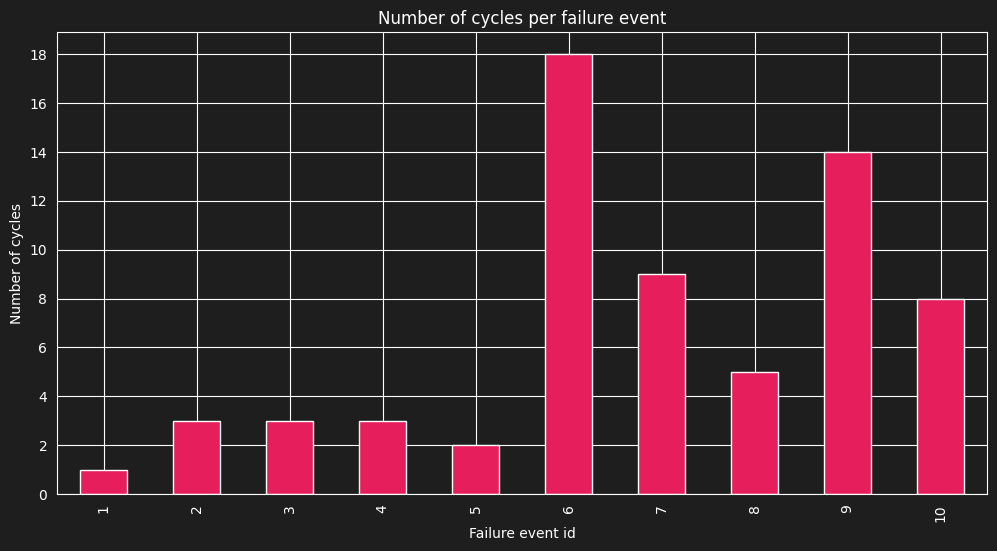

In [32]:
from matplotlib.ticker import MaxNLocator
from matplotlib import pyplot as plt

# Plotting the number of cycles per failure event
failures = df.query('Fail == True').groupby('Fail_index').size()

print(f"Median number of cycles per failure event: {failures.median()}")

ax = failures.plot(kind='bar', figsize=(12, 6), title='Number of cycles per failure event')
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_ylabel('Number of cycles')
ax.set_xlabel('Failure event id')

plt.show()

It is now evident that failure events 6 through 10 lasted significantly longer than the first five. Notably, event 3 exceeded the average failure duration by nearly three times and the median by six times.

This trend of increasingly prolonged failure events over time may indicate chronic issues with the FPSO equipment or operational challenges. It represents a critical concern that must be addressed to minimize the impact of extended downtime on oil extraction.

The following analysis will look at these events in greater detail to better understand their characteristics and potential root causes.

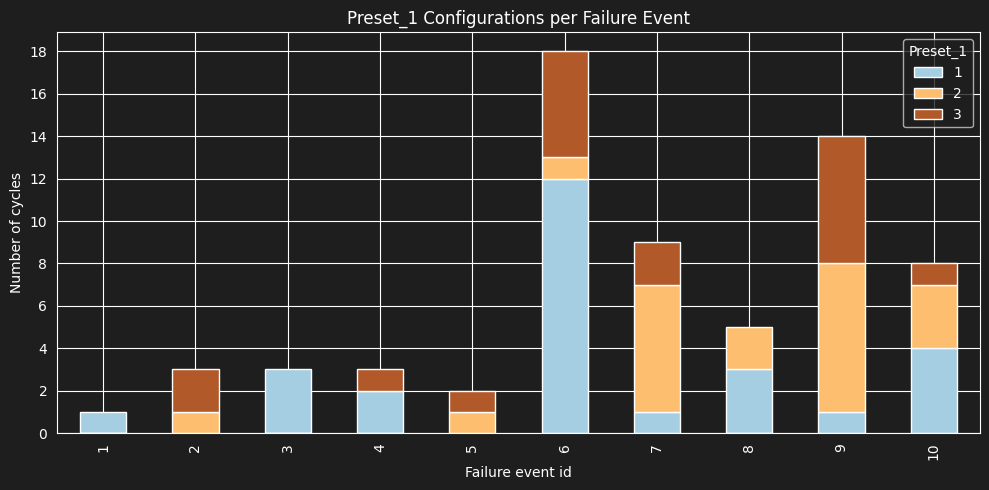

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))

# Stacked barplot for Preset_1 configurations per failure event
df.query('Fail==True').groupby(['Fail_index', 'Preset_1']).size().unstack().plot(
    kind='bar',
    stacked=True,
    colormap='Paired',
    ax=ax
)

# Adjust axes and labels
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_ylabel('Number of cycles')
ax.set_xlabel('Failure event id')
ax.set_title('Preset_1 Configurations per Failure Event')

plt.tight_layout()
plt.show()

The barplot reveals important operational patterns during individual failure events:

**Configuration Switching During Failures:**
- Multiple Preset_1 settings are actively used within individual failure events, indicating operators systematically attempt different configurations to restore normal operation
- This configuration switching behavior is most pronounced in longer failure events (6-10)

**Preset_1 Usage Patterns:**
- **Preset_1=1**: Predominant in the longest failure event (Event 6);
- **Preset_1=2**: Appeared frequently in major critical failures (Events 7 and 9);
- **Preset_1=3**: Least utilized across nearly all failure events.

This pattern indicates that operational strategy becomes more aggressive and varied as failures persist, with operators cycling through available configurations in an attempt to restore normal state.

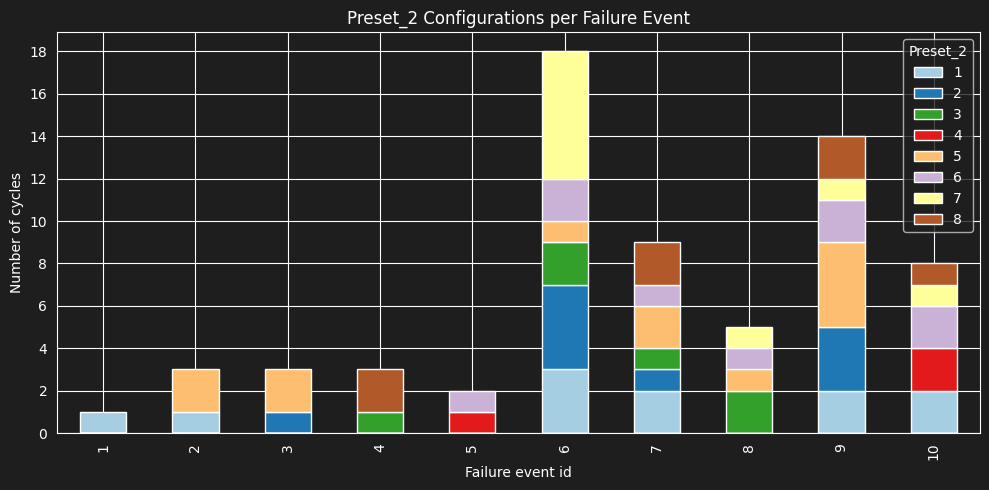

In [34]:
# Create a larger figure
fig, ax = plt.subplots(figsize=(10, 5))

# Stacked barplot for Preset_2 configurations per failure event
df.query('Fail==True').groupby(['Fail_index', 'Preset_2']).size().unstack().plot(
    kind='bar',
    stacked=True,
    colormap='Paired',
    ax=ax
)

# Adjust axes and labels
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_ylabel('Number of cycles')
ax.set_xlabel('Failure event id')
ax.set_title('Preset_2 Configurations per Failure Event')

plt.tight_layout()
plt.show()

When analyzing **Preset_2**, similar behavior can be found.

**Configuration Diversity During Failures:**
- Multiple Preset_2 values are actively used within individual failure events, indicating operators are systematically trying different configurations to restore normal operation
- This configuration switching behavior is most pronounced in longer failure events (6-10)

**Temporal Pattern in Later Failures:**
- **Preset_2=7 and Preset_2=6** appears consistently across nearly all extended failure periods;
- **Preset_2=5** is used in 60% of all events, but usually for few operation cycles each time.

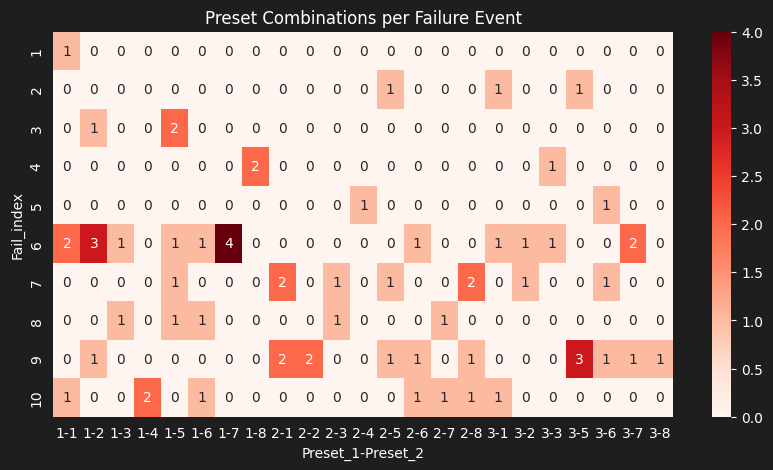

In [35]:
fig, ax = plt.subplots(figsize=(10, 5))

# Create a pivot table showing combinations for each failure event
combo_heatmap = df.query('Fail == True').reset_index().pivot_table(
    values='Cycle', 
    index='Fail_index', 
    columns=['Preset_1', 'Preset_2'], 
    aggfunc='count', 
    fill_value=0
)

sns.heatmap(combo_heatmap, annot=True, cmap='Reds', fmt='d')
plt.title('Preset Combinations per Failure Event')
plt.show()

When analyzing Preset combinations (Preset_1–Preset_2), similar patterns emerge.

**Configuration During Failures:**
- Multiple Preset combinations are used within individual failure events, reflecting a effort to adjust configurations in response to equipment issues;
- This switching behavior is more evident in longer failure events (6–10), where operators or automated controls tried many different combinations;
- Certain configurations, such as Preset_1=1 with Preset_2=7 and Preset_1=1 with Preset_2=6, become more prominent during extended failures, especially in events 6–10.

Besides the equipment configuration, it is also important to examine the sensor data behavior during the failure events. This will help reveal how failures manifest in these variables and may allow the identification of different root causes.

In [36]:
def plot_failure_summary_heatmap(df: pd.DataFrame, target_col: str = 'Fail_index', agg_funcs: List[str] = ['mean', 'max', 'median'],
                                figsize: tuple = (16, 10),
                                title: str = "Failure Events Summary - Sensor Statistics") -> None:
    """    Creates a heatmap of failure summary statistics with separate scaling for each variable.
    Args:
        df (pd.DataFrame): DataFrame with failure statistics by event
        target_col (str): Target column name for grouping.  
        agg_funcs (List[str]): List of aggregation functions to apply.
        figsize (tuple): Figure size
        title (str): Plot title
    """
    failures_summary = create_stats_summary(df, target_col=target_col, agg_funcs=agg_funcs)

    # Flatten the multi-level columns for easier processing
    df_flat = failures_summary.copy()
    df_flat.columns = [f"{col[0]}_{col[1]}" for col in df_flat.columns]
    
    # Separate sensor variables from duration
    sensor_cols = [col for col in df_flat.columns if col != f"{target_col}_count"]

    # Create figure with subplots
    fig, axes = plt.subplots(1, 2, figsize=figsize, gridspec_kw={'width_ratios': [4, 1]})
    
    # Plot 1: Sensor variables heatmap (normalized by column)
    sensor_data = df_flat[sensor_cols]
    sensor_normalized = sensor_data.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=0)
    
    sns.heatmap(sensor_normalized, 
                annot=sensor_data.round(1),  # Show actual values
                cmap='RdYlBu_r', 
                cbar_kws={'label': 'Normalized Scale (0-1)'}, 
                ax=axes[0],
                fmt='g')
    
    axes[0].set_title('Sensor Variables (Each Column Independently Scaled)')
    axes[0].set_ylabel('Failure Event ID')
    
    # Plot 2: Duration heatmap
    duration_data = df_flat[[f"{target_col}_count"]]
    duration_normalized = (duration_data - duration_data.min()) / (duration_data.max() - duration_data.min())
    
    sns.heatmap(duration_normalized,
                annot=duration_data,
                cmap='Reds',
                cbar_kws={'label': 'Duration Scale'},
                ax=axes[1],
                fmt='g')
    
    axes[1].set_title('Duration\n(Cycles)')
    axes[1].set_ylabel('')
    
    plt.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

Temperature                         Pressure                       \
                  mean       max        std        mean       max        std   
Fail_index                                                                     
1            79.806500   79.8065        NaN  103.129700  103.1297        NaN   
2            89.793400   91.6953   1.648740   90.935467   99.2287   7.325686   
3           105.646633  105.9694   0.349649  149.796900  189.9957  39.661919   
4           102.186967  115.2786  12.534631   91.952133  114.2295  20.071311   
5           106.528700  106.5889   0.085136  109.283950  129.4164  28.471584   
6            81.412172  106.7484  20.099746  118.305656  179.8189  40.760012   
7           102.631244  150.8803  29.619151  113.135444  160.0359  24.468626   
8            97.630860  119.6257  17.185138  103.143800  120.9359  10.822768   
9            95.510786  125.0366  16.848968  121.211643  168.4883  22.643369   
10           87.851475  127.6708  30.563518  125.466725  160.4336  24.599448   

            VibrationX                       VibrationY                       \
                  mean       max        std        mean       max        std   
Fail_index                                                                     
1           120.753100  120.7531        NaN  134.500900  134.5009        NaN   
2            91.380267   99.8907   7.632735  114.658167  124.9342  16.751221   
3            87.096200  102.2722  16.294318  167.350100  193.5699  22.716728   
4            92.082100  114.8593  20.293987   99.278567  116.3420  14.779222   
5           110.283350  129.7686  27.556305   99.313450  108.0637  12.374722   
6           106.975772  200.7496  42.470806  125.920950  180.8705  39.968608   
7           107.141511  130.0623  16.759370  115.109489  150.6206  27.501266   
8            97.267500  120.8147  16.897965  115.362860  135.5254  15.147503   
9            90.278700  128.3579  17.868311  119.466314  170.5197  25.483081   
10          102.245262  151.5853  30.794499  131.857888  169.7738  30.037741   

            VibrationZ                        Frequency                       \
                  mean       max        std        mean       max        std   
Fail_index                                                                     
1           115.873200  115.8732        NaN   76.562900   76.5629        NaN   
2            99.376567  124.9703  22.281087   90.941567  100.2291   8.269319   
3           103.069733  119.1361  14.698026  134.016733  141.5029   6.532205   
4            96.237633  115.1043  21.083745   99.621167  113.7843  13.998078   
5           153.791500  154.2559   0.656761  100.842550  111.2816  14.763046   
6           113.727750  200.2427  42.238767  101.289817  178.0903  34.023272   
7           106.717922  129.3918  17.165716   93.042178  115.3036  12.030937   
8            96.624160  118.7961  15.730465  114.371660  126.2924  13.563635   
9            91.870686  129.9870  16.297279  102.017500  122.0462   9.981906   
10          112.479087  148.8385  21.180788   84.369375  110.9193  19.967592   

           Fail_index  
                count  
Fail_index             
1                   1  
2                   3  
3                   3  
4                   3  
5                   2  
6                  18  
7                   9  
8                   5  
9                  14  
10                  8

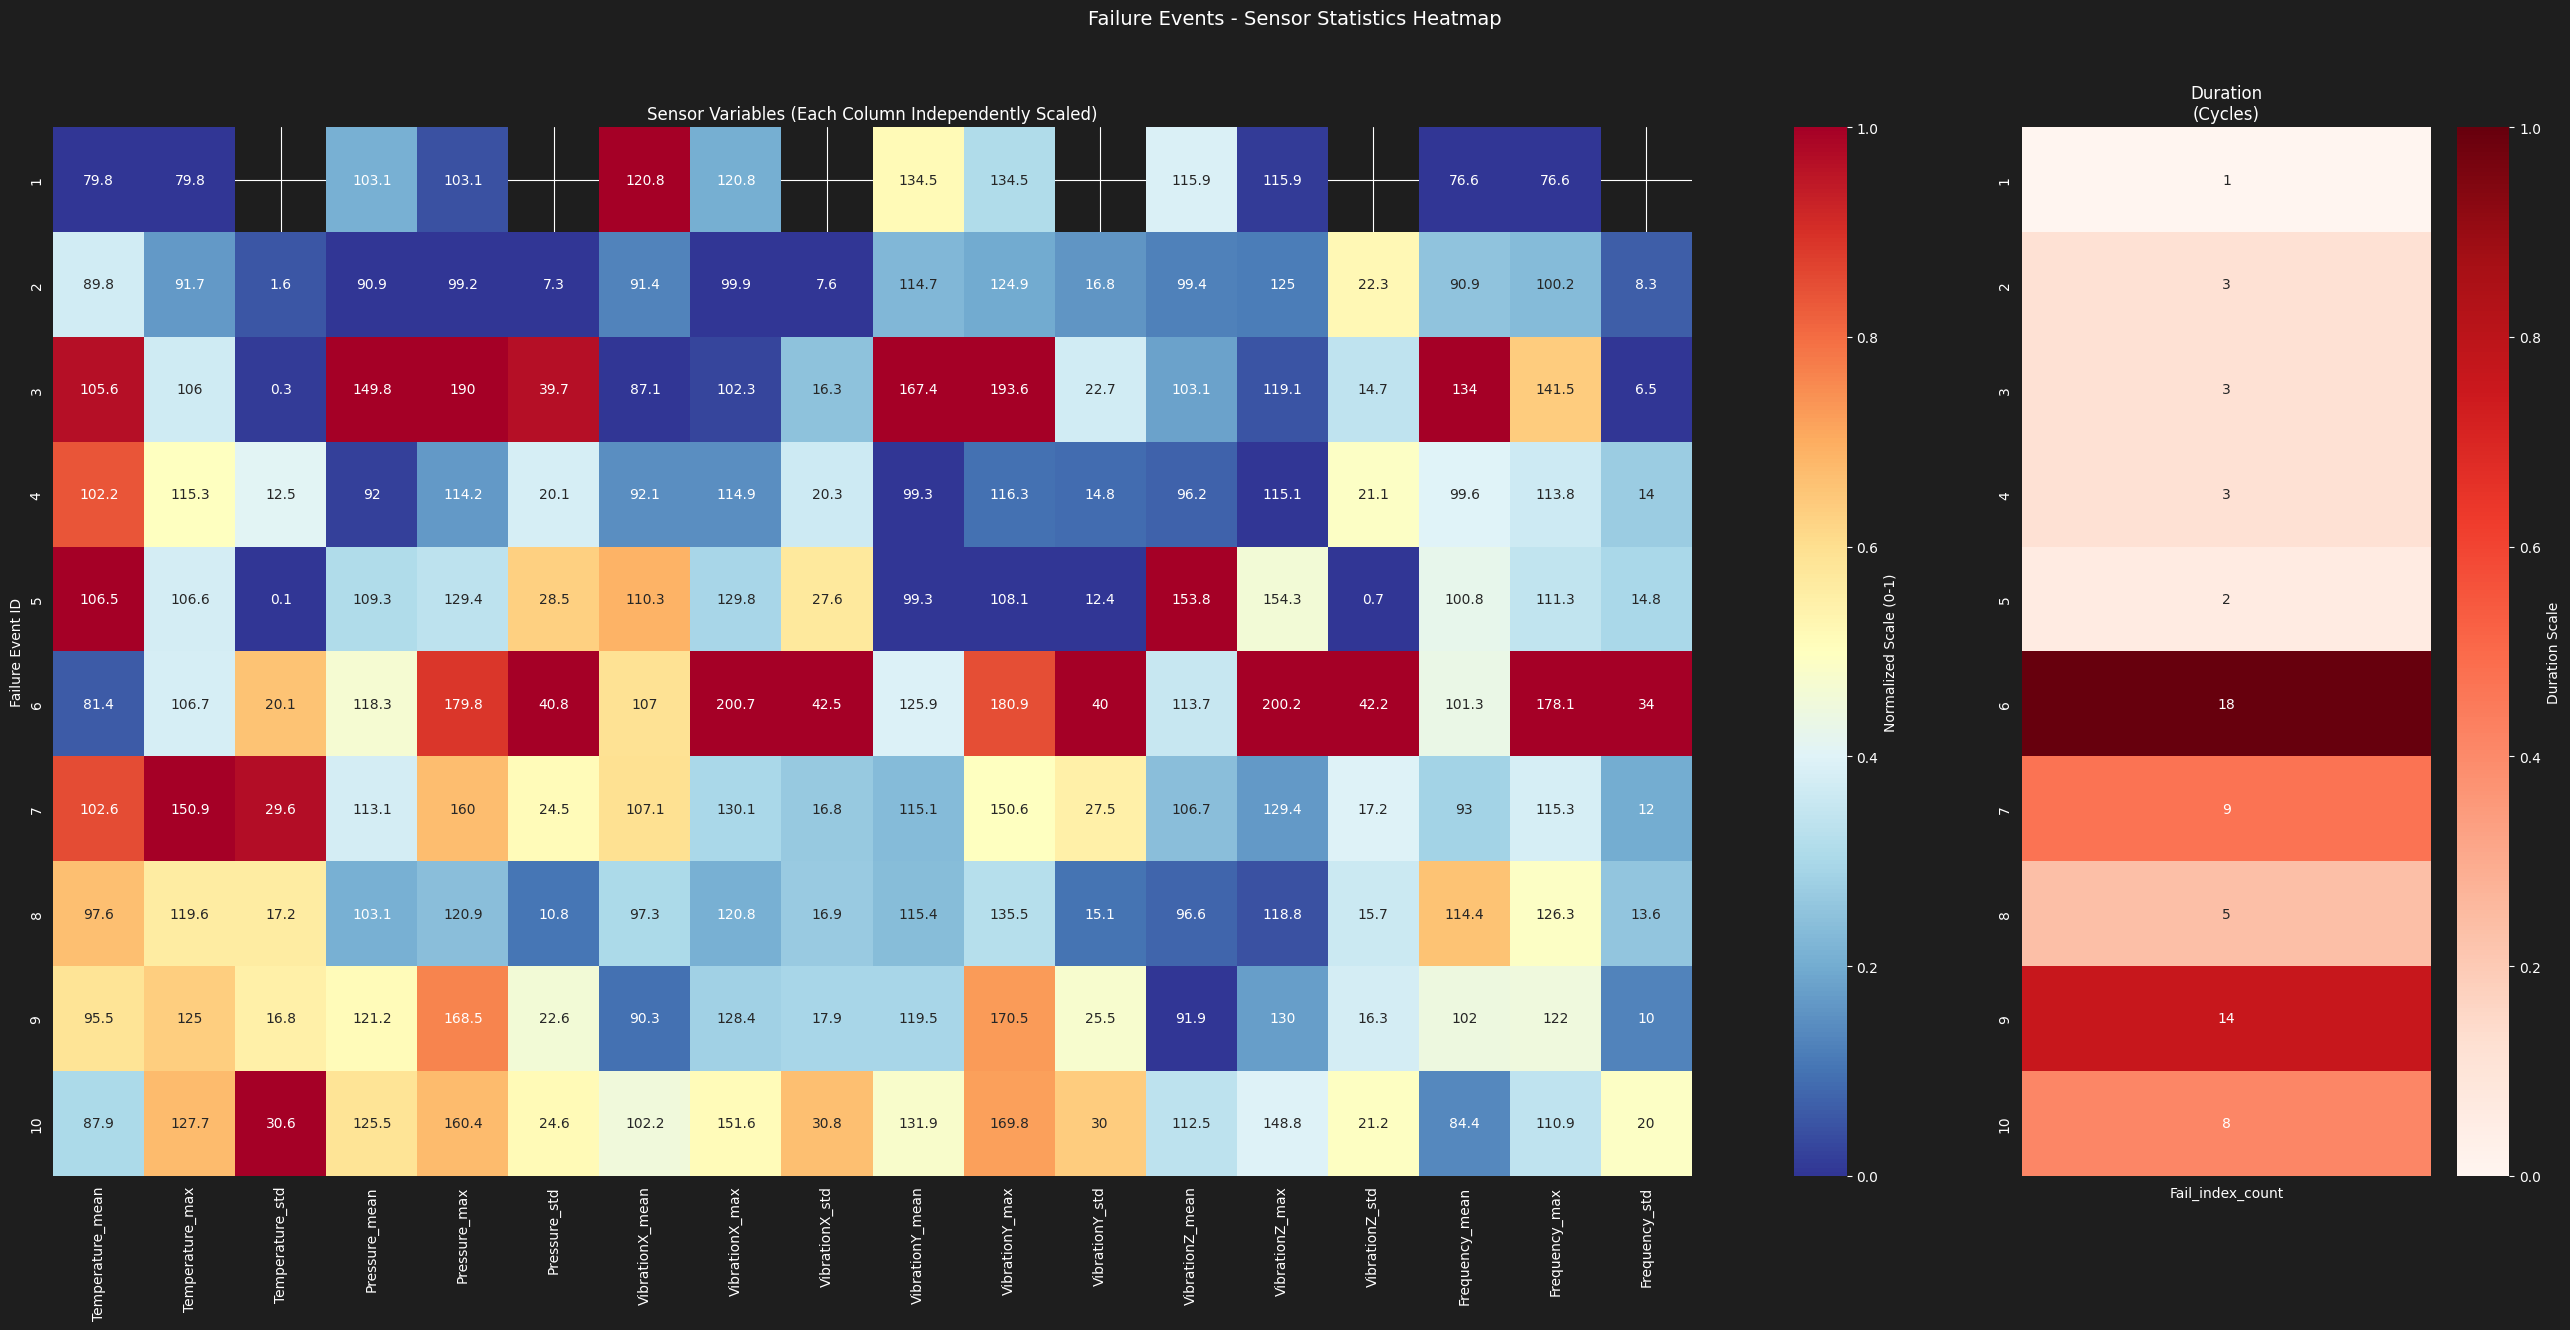

In [37]:
# Create heatmap visualization
failure_summary = create_stats_summary(df.query("Fail == True"), target_col='Fail_index', agg_funcs=['mean', 'max', 'std'])
display(failure_summary)

# Create heatmap visualization
plot_failure_summary_heatmap(df.query("Fail == True"), 
                            figsize=(26, 13),
                            agg_funcs=['mean', 'max', 'std'],
                            title="Failure Events - Sensor Statistics Heatmap")

Interesting insights can be drawn from the general statistics of sensor data across each failure event.

**Short failures (Events 1-5):**
- Last up to 3 operation cycles.
- Marked by sharp peaks in temperature and vibration, usually with low variability (STD).
- Events 3, 4, and 5 show notably high Temperature, with Event 3 having very high variability (STD ~30), suggesting instability.
- High VibrationX in Event 1 and VibrationZ in Event 5, both with low variability — indicating brief but intense conditions.
- Event 3 stands out with high values in most variables and high variability in Temperature and Pressure — likely an outlier.
- General pattern: Sudden, short-lived failures. Event 3 may indicate a different failure mechanism.

**Long failures (Events 6-10):**
Last 5 or more cycles.
- Characterized by consistently high values in vibration and pressure, with generally higher variability;
- Event 6 shows extreme variability (e.g., VibrationX STD ~43), suggesting mechanical instability;
- Event 7 has the highest Temperature, but moderate variability;
- Event 10 combines high Temperature and VibrationZ variability;
- Events 8 and 9 have high readings but lower variability;
- General pattern: Long and chronic failures, with some events being much more unstable (6 and 10).


One possible interpretation is that during short failures, the equipment experienced sudden peaks in sensor readings that quickly returned to normal levels. In longer failures, these variables sustained abnormal levels over time, reinforcing the hypothesis of potentially chronic mechanical or process issues. This may also indicate a progressive deterioration in equipment condition over the analyzed period.

Clustering can be useful in this context to validate the above grouping of similar failure events based on sensor behavior.

In [38]:
# Cluster failure events based on sensor characteristics
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Standardize and cluster
scaler = StandardScaler()
scaled_features = scaler.fit_transform(failure_summary.fillna(0))

kmeans = KMeans(n_clusters=2, random_state=42)
failure_clusters = kmeans.fit_predict(scaled_features)

failure_summary['Cluster'] = failure_clusters
clusters = {}

print("Failure Event Clusters:")
for i, cluster in enumerate(failure_clusters):
    print(f"Event {i+1}: Cluster {cluster}")
    clusters[i+1] = cluster

Failure Event Clusters:
Event 1: Cluster 0
Event 2: Cluster 0
Event 3: Cluster 1
Event 4: Cluster 0
Event 5: Cluster 0
Event 6: Cluster 1
Event 7: Cluster 1
Event 8: Cluster 0
Event 9: Cluster 1
Event 10: Cluster 1


The two clusters align closely with the initial interpretation of short and long failure periods. The only difference is the reassignment of Event 3 and Event 8, now labeled as Cluster 1 and Cluster 0, respectively. This reassignment is reasonable, as Event 3 showed unusually high variability for a short failure, resembling long failures more closely.

To better highlight these differences, it is helpful to recompute a summary of descriptive statistics by cluster.

In [39]:
# Addition of cluster column on the main DataFrame
df['Clusters'] = df['Fail_index'].map(clusters)

create_stats_summary(df.query('Fail == True'),
                     target_col='Clusters',
                     agg_funcs=['mean', 'max', 'std'])

Temperature                         Pressure                       \
                mean       max        std        mean       max        std   
Clusters                                                                     
0.0        96.925664  119.6257  13.057960   99.005671  129.4164  14.808425   
1.0        91.269288  150.8803  23.427925  121.111698  189.9957  31.440983   

          VibrationX                       VibrationY                       \
                mean       max        std        mean       max        std   
Clusters                                                                     
0.0        98.431743  129.7686  17.315598  110.839450  135.5254  16.270682   
1.0       100.634423  200.7496  30.488730  125.615467  193.5699  33.154241   

          VibrationZ                        Frequency                       \
                mean       max        std        mean       max        std   
Clusters                                                                     
0.0       106.672829  154.2559  25.402020  101.556750  126.2924  15.880806   
1.0       105.822929  200.2427  29.354805   99.343202  178.0903  24.628445   

         Clusters  
            count  
Clusters           
0.0            14  
1.0            52

The data reveals that Cluster 1, which includes most long-duration failures, exhibits significantly higher values and variability in key variables like **Pressure** and **VibrationY**. Failures in this cluster also show the highest maximum readings across all sensor variables. In contrast, **Frequency** and **VibrationZ** display more consistent behavior across both clusters, suggesting these variables are less discriminative for failure type

### Key Findings of Section 3.1.4: Failure event analysis

**Count of Failure Events:** The equipment had 10 failure events during the period of 800 cycles.

**Failure Durations:**
- **Short failures** (Events 1, 2, 4, 5): Lasted 1–3 cycles, with quick spikes and recoveries
- **Long failures** (Events 6–10): Lasted 5+ cycles, showing sustained issues
- Failures became longer over time, pointing to progressive degradation

**Preset configurations during failures:**
- **Configuration Switching Strategy**: Multiple preset combinations are used within individual failure events, indicating operators systematically attempt different configurations to restore normal operation;
- **Escalating Complexity**: Configuration switching behavior becomes most pronounced in longer failure events (6-10);
- **Preset_1 Patterns**:
  - **Preset_1=1**: Predominant in the longest failure event (Event 6) and critical shorter events
  - **Preset_1=2**: Frequently used in major critical failures (Events 7 and 9)
  - **Preset_1=3**: Least utilized across nearly all failure events
- **Preset_2 Temporal Evolution**: 
  - **Preset_2=6 and Preset_2=7** become dominant in later failure events (5-10)

**Sensor Behavior:**
- **VibrationY** and **Pressure** had the most noticeable increases during failures
- **Temperature** peaked in Events 3, 4, 5, and 7
- **Variability (STD)** revealed two patterns:
  - **Low STD:** Stable spikes (acute issues)
  - **High STD:** Erratic behavior (unstable failures)

**Failure Clusters:**
- **Cluster 0** (Events 1, 2, 4, 5, 8): Stable failures, low variability
- **Cluster 1** (Events 3, 6, 7, 9, 10): Unstable failures, high variability

**Notable Events:**
- **Event 3:** Short but highly unstable – reclassified correctly due to extreme STD
- **Event 6:** Longer and most unstable – VibrationX STD ~43
- **Event 8:** A long but stable failure, possibly with a different root cause

**Conclusion:** Failures are becoming more frequent and unstable, reinforcing the need for preventive maintenance to avoid critical breakdowns.

### 3.1.5 Pre-failure event analysis

Besides analyzing equipment behavior during failures, it is also important to understand how the sensor variables behaved in the moments leading up to these events. To achieve this, a good approach is to analyze failure events with buffers of operation cycles preceding each failure onset. This can help identify early indicators or gradual trends that precede equipment failures.

In [40]:
def get_buffer_around_index(df: pd.DataFrame, 
                           start_index: int, 
                           stop_index: int,
                           buffer_before: int = 5,
                           buffer_after: int = 5,
                           exclude_failure_cycles: bool = False) -> pd.DataFrame:
    """
    Extracts cycles before and after a specific index for analysis of patterns around that point.
    
    Args:
        df (pd.DataFrame): DataFrame with the data
        start_index (int): The start index around which to create the buffer
        stop_index (int): The stop index around which to create the buffer
        buffer_before (int): Number of cycles before the start index to include
        buffer_after (int): Number of cycles after the stop index to include
        exclude_failure_cycles (bool): If True, excludes cycles that are already in failure
        
    Returns:
        pd.DataFrame: DataFrame containing only the cycles in the buffer around target index
    """
    buffer_indices = []
    
    # Calculate the range of the buffer
    start_buffer = start_index - buffer_before
    end_buffer = stop_index + buffer_after-1
    
    # Ensure we don't go beyond the dataset boundaries
    start_buffer = max(start_buffer, df.index.min())
    end_buffer = min(end_buffer, df.index.max())
    
    # Add indices to buffer if they exist in the dataset
    for idx in range(start_buffer, end_buffer + 1):
        if idx in df.index:
            # If exclude_failure_cycles=True, only add if not in failure
            if exclude_failure_cycles:
                if not df.loc[idx, 'Fail']:
                    buffer_indices.append(idx)
            else:
                buffer_indices.append(idx)
    
    # Remove duplicates and sort
    buffer_indices = sorted(list(set(buffer_indices)))
    
    # Return the subset of DataFrame
    return df.loc[buffer_indices].copy()

In [41]:
for event in failure_events['events']:
    print(f"Failure event from cycle {event[0]} to {event[1]}")
    buffer = get_buffer_around_index(df,
                                    start_index=event[0],
                                    stop_index=event[0],
                                    buffer_before=3,
                                    buffer_after=1,
                                    exclude_failure_cycles=False)

    display(buffer)
    display(buffer.select_dtypes(float).std())
    print('\n')

Failure event from cycle 13 to 14


,Preset_1,Preset_2,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency,Fail,Fail_index,Clusters
Cycle,,,,,,,,,,,
10,1,8,42.6192,48.3433,65.7892,49.5248,64.9151,41.6207,False,0,NaN
11,2,5,59.5014,64.4693,79.0678,65.8915,79.4462,60.2082,False,0,NaN
12,2,5,80.6625,84.2735,99.6288,83.7019,103.1410,77.8884,False,0,NaN
13,1,1,79.8065,103.1297,120.7531,134.5009,115.8732,76.5629,True,1,0.0


Temperature    18.202607
Pressure       23.795948
VibrationX     24.064367
VibrationY     36.812452
VibrationZ     22.948455
Frequency      16.989264
Clusters             NaN
dtype: float64



Failure event from cycle 157 to 160


,Preset_1,Preset_2,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency,Fail,Fail_index,Clusters
Cycle,,,,,,,,,,,
154,2,2,79.7849,105.1179,66.4159,59.4661,74.2734,129.1288,False,0,NaN
155,3,8,79.5837,135.1351,86.1479,70.1276,95.0881,148.4044,False,0,NaN
156,2,5,159.5474,110.2718,65.1477,64.9867,110.3055,28.4115,False,0,NaN
157,3,1,91.6953,85.3458,99.8907,95.3284,124.9703,84.3774,True,2,0.0


...

,Preset_1,Preset_2,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency,Fail,Fail_index,Clusters
Cycle,,,,,,,,,,,
697,1,8,91.2214,103.9528,89.3264,124.2531,89.1871,97.7817,False,0,NaN
698,2,8,53.6886,86.6445,56.0243,49.9237,56.3788,59.9455,False,0,NaN
699,2,5,84.0818,61.2008,66.4745,134.7877,105.3061,98.0923,False,0,NaN
700,2,1,89.9807,89.4484,128.3579,91.6058,72.8418,106.6816,True,9,1.0


Temperature    17.646729
Pressure       17.773714
VibrationX     32.048932
VibrationY     38.194302
VibrationZ     21.059870
Frequency      20.864843
Clusters             NaN
dtype: float64



Failure event from cycle 793 to 801


,Preset_1,Preset_2,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency,Fail,Fail_index,Clusters
Cycle,,,,,,,,,,,
790,2,3,95.5450,116.4443,185.1342,43.6493,46.0053,25.4544,False,0,NaN
791,3,7,39.9099,29.7978,34.5756,44.5606,41.5884,53.5847,False,0,NaN
792,2,7,84.9908,70.5072,78.6738,96.3826,79.1318,121.8506,False,0,NaN
793,1,6,127.6708,131.5159,95.5828,132.0539,97.2541,97.7765,True,10,1.0


Temperature    36.279664
Pressure       46.161740
VibrationX     63.228162
VibrationY     43.021355
VibrationZ     26.739341
Frequency      43.307753
Clusters             NaN
dtype: float64

This preliminary analysis of the operation cycles preceding failures shows a consistent increase in sensor readings leading up to the failure events. In nearly all 10 recorded failures, at least one variable exhibited a sharp rise or significant variation shortly before the failure occurred.

Therefore, using rolling windows to create new features is a promising approach to predict equipment failures and uncover distinct patterns among different failure types.

In [58]:
def calculate_pre_failure_rolling_features(df: pd.DataFrame, 
                                         failure_events: dict,
                                         buffer_size: int = 4,
                                         windows: List[int] = [3],
                                         sensor_cols: List[str] = None) -> pd.DataFrame:
    """
    Calculate rolling window features for cycles preceding each failure event.
    Uses existing get_buffer_around_index function.
    
    Args:
        df (pd.DataFrame): Main DataFrame with sensor data
        failure_events (dict): Dictionary with failure events (from find_failure_transitions)
        buffer_size (int): Number of cycles before failure to analyze
        windows (List[int]): Window sizes for rolling calculations
        sensor_cols (List[str]): Sensor columns to analyze. If None, uses float columns
        
    Returns:
        pd.DataFrame: DataFrame with pre-failure rolling features for each event
    """
    if sensor_cols is None:
        sensor_cols = df.select_dtypes(include=['float64']).columns.tolist()
    
    pre_failure_features = []
    
    # Iterate through each failure event
    for event_idx, (start_cycle, _) in enumerate(failure_events['events']):
        # Use existing function to get buffer
        buffer_data = get_buffer_around_index(
            df=df,
            start_index=start_cycle,
            stop_index=start_cycle,  # Only need start point
            buffer_before=buffer_size,
            buffer_after=1,  # buffer = 1 to consider failure start point
            exclude_failure_cycles=False  # Exclude cycles already in failure
        )
        
        if len(buffer_data) > 0:
            # Calculate rolling features for this buffer
            event_features = {'Fail_index': event_idx + 1}
            
            for window in windows:
                for col in sensor_cols:
                    if col in buffer_data.columns:
                        # Rolling statistics, get value from the beginning of the failure
                        rolling_mean = buffer_data[col].rolling(window=window, min_periods=1).mean().iloc[-1]
                        rolling_std = buffer_data[col].rolling(window=window, min_periods=1).std().iloc[-1]
                        
                        # Calculate percent change
                        # If buffer is smaller than window, set pct_change to 0
                        if len(buffer_data) > window:
                            pct_change = buffer_data[col].pct_change(periods=window).iloc[-1]
                        else:
                            pct_change = 0
                        
                        # Store features
                        event_features[f'{col}_rolling_mean_{window}'] = rolling_mean
                        event_features[f'{col}_rolling_std_{window}'] = rolling_std
                        event_features[f'{col}_pct_change_{window}'] = pct_change
            
            pre_failure_features.append(event_features)
    
    return pd.DataFrame(pre_failure_features)

# Usage:
pre_failure_df = calculate_pre_failure_rolling_features(
    df=df,
    failure_events=failure_events,
    buffer_size=2,
    windows=[3],
    sensor_cols=['Temperature', 'Pressure', 'VibrationX', 'VibrationY', 'VibrationZ', 'Frequency']
)

print(f"Pre-failure features shape: {pre_failure_df.shape}")
display(pre_failure_df)

Pre-failure features shape: (10, 19)


,Fail_index,Temperature_rolling_mean_3,Temperature_rolling_std_3,Temperature_pct_change_3,Pressure_rolling_mean_3,Pressure_rolling_std_3,Pressure_pct_change_3,VibrationX_rolling_mean_3,VibrationX_rolling_std_3,VibrationX_pct_change_3,VibrationY_rolling_mean_3,VibrationY_rolling_std_3,VibrationY_pct_change_3,VibrationZ_rolling_mean_3,VibrationZ_rolling_std_3,VibrationZ_pct_change_3,Frequency_rolling_mean_3,Frequency_rolling_std_3,Frequency_pct_change_3
0,1,73.323467,11.977910,0,83.957500,19.332137,0,99.816567,20.843284,0,94.698100,35.601963,0,99.486800,18.486386,0,71.553167,9.847357,0
1,2,110.275467,43.098321,0,110.250900,24.894657,0,83.728767,17.497376,0,76.814233,16.238472,0,110.121300,14.941952,0,87.064433,60.041562,0
2,3,86.012433,23.872450,0,109.917800,25.760586,0,82.389600,15.505760,0,107.138433,42.657066,0,86.931467,15.426477,0,93.409700,33.156230,0
3,4,146.485500,94.516717,0,58.668167,42.730365,0,63.868367,49.090437,0,76.918767,38.414075,0,101.607133,32.073588,0,89.831567,30.278455,0
4,5,102.462100,3.601797,0,128.827133,37.561977,0,130.684533,19.919800,0,94.489667,3.475190,0,124.035133,27.974229,0,81.159133,26.486512,0
5,6,79.230667,1.105626,0,127.481967,23.115267,0,160.019533,37.060070,0,82.773600,28.504557,0,99.107300,9.413706,0,77.670200,30.843404,0
6,7,59.259033,13.479870,0,67.372900,5.334262,0,115.246500,12.830999,0,95.202200,17.164758,0,113.121200,14.113575,0,89.622767,6.029467,0
7,8,83.928967,15.830195,0,90.476100,9.947971,0,89.446400,10.969360,0,105.401933,28.082033,0,89.935167,9.225166,0,101.878433,23.234966,0
8,9,75.917033,19.475027,0,79.097900,15.562619,0,83.618900,39.095847,0,92.105733,42.434209,0,78.175567,24.895923,0,88.239800,24.877089,0
9,10,84.190500,43.885923,0,77.273633,51.195522,0,69.610733,31.497206,0,90.999033,43.994391,0,72.658100,28.391885,0,91.070600,34.623476,0


In [59]:
# Standardize and cluster
scaler = StandardScaler()
scaled_features = scaler.fit_transform(pre_failure_df.fillna(0))

kmeans = KMeans(n_clusters=2, random_state=42)
pre_failure_clusters = kmeans.fit_predict(scaled_features)

pre_failure_df['Cluster'] = pre_failure_clusters
clusters = {}

print("Failure Event Clusters:")
for i, cluster in enumerate(pre_failure_clusters):
    print(f"Event {i+1}: Cluster {cluster}")
    clusters[i+1] = cluster

Failure Event Clusters:
Event 1: Cluster 1
Event 2: Cluster 1
Event 3: Cluster 1
Event 4: Cluster 0
Event 5: Cluster 1
Event 6: Cluster 1
Event 7: Cluster 1
Event 8: Cluster 1
Event 9: Cluster 1
Event 10: Cluster 0


In [60]:
# Dataframe with pre-failure rolling features and clusters
display(pre_failure_df)

,Fail_index,Temperature_rolling_mean_3,Temperature_rolling_std_3,Temperature_pct_change_3,Pressure_rolling_mean_3,Pressure_rolling_std_3,Pressure_pct_change_3,VibrationX_rolling_mean_3,VibrationX_rolling_std_3,VibrationX_pct_change_3,VibrationY_rolling_mean_3,VibrationY_rolling_std_3,VibrationY_pct_change_3,VibrationZ_rolling_mean_3,VibrationZ_rolling_std_3,VibrationZ_pct_change_3,Frequency_rolling_mean_3,Frequency_rolling_std_3,Frequency_pct_change_3,Cluster
0,1,73.323467,11.977910,0,83.957500,19.332137,0,99.816567,20.843284,0,94.698100,35.601963,0,99.486800,18.486386,0,71.553167,9.847357,0,1
1,2,110.275467,43.098321,0,110.250900,24.894657,0,83.728767,17.497376,0,76.814233,16.238472,0,110.121300,14.941952,0,87.064433,60.041562,0,1
2,3,86.012433,23.872450,0,109.917800,25.760586,0,82.389600,15.505760,0,107.138433,42.657066,0,86.931467,15.426477,0,93.409700,33.156230,0,1
3,4,146.485500,94.516717,0,58.668167,42.730365,0,63.868367,49.090437,0,76.918767,38.414075,0,101.607133,32.073588,0,89.831567,30.278455,0,0
4,5,102.462100,3.601797,0,128.827133,37.561977,0,130.684533,19.919800,0,94.489667,3.475190,0,124.035133,27.974229,0,81.159133,26.486512,0,1
5,6,79.230667,1.105626,0,127.481967,23.115267,0,160.019533,37.060070,0,82.773600,28.504557,0,99.107300,9.413706,0,77.670200,30.843404,0,1
6,7,59.259033,13.479870,0,67.372900,5.334262,0,115.246500,12.830999,0,95.202200,17.164758,0,113.121200,14.113575,0,89.622767,6.029467,0,1
7,8,83.928967,15.830195,0,90.476100,9.947971,0,89.446400,10.969360,0,105.401933,28.082033,0,89.935167,9.225166,0,101.878433,23.234966,0,1
8,9,75.917033,19.475027,0,79.097900,15.562619,0,83.618900,39.095847,0,92.105733,42.434209,0,78.175567,24.895923,0,88.239800,24.877089,0,1
9,10,84.190500,43.885923,0,77.273633,51.195522,0,69.610733,31.497206,0,90.999033,43.994391,0,72.658100,28.391885,0,91.070600,34.623476,0,0


This clustering approach focuses on identifying different root causes of failures by analyzing how sensored variables behave in the cycles leading up to failure events. Based on this, two clusters were formed:

- Cluster 0: Events 2, 4, 10
- Cluster 1: Events 1, 3, 5, 6, 7, 8, 9

This suggests the presence of two distinct pre-failure behavior patterns, which may reflect different failure mechanisms or root causes across events.

In [61]:
# Statistics summary for pre-failure features by cluster
create_stats_summary(pre_failure_df, target_col='Cluster', agg_funcs=['mean'])

,Temperature_rolling_mean_3,Temperature_rolling_std_3,Pressure_rolling_mean_3,Pressure_rolling_std_3,VibrationX_rolling_mean_3,VibrationX_rolling_std_3,VibrationY_rolling_mean_3,VibrationY_rolling_std_3,VibrationZ_rolling_mean_3,VibrationZ_rolling_std_3,Frequency_rolling_mean_3,Frequency_rolling_std_3,Cluster
,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,count
Cluster,,,,,,,,,,,,,
0,115.338000,69.20132,67.970900,46.962943,66.73955,40.293822,83.958900,41.204233,87.132617,30.232737,90.451083,32.450966,2
1,83.801146,16.55515,99.672775,20.188684,105.61885,21.715312,93.577988,26.769781,100.114242,16.809677,86.324704,26.814573,8


Clear differences can be found between those clusters:
- Temperature: Higher mean and variability in Cluster 0 — suggesting sharp spikes before failure. In Cluster 1, values are lower and more stable.
- Pressure: Higher and more variable in Cluster 1 — indicating buildup over time.
- Vibrations: Stronger and more consistent in Cluster 1; more erratic in Cluster 0.
- Frequency: Slightly more variation in Cluster 0; overall similar.

Understanding these distinct pre-failure signatures could allow monitoring approaches:

- **Cluster 0 (Temperature-Driven Failures)**: Characterized by sudden temperature spikes with high variability before failure. These events require immediate alerts when temperature volatility exceeds normal ranges.

- **Cluster 1 (Pressure/Vibration-Driven Failures)**: Marked by gradual buildup in pressure and vibration levels with sustained elevation. These failures could benefit from **trend-based monitoring** that tracks progressive deterioration over multiple cycles.


The same logic could be used to analyze patterns on equipment setups. Below the analyzis main goal is to identify the combinations of **Preset_1** and **Preset_2** that are most frequent in operation cycles before failures.

In [55]:
# Create a DataFrame to hold pre-failure data
presets_pre_failure = pd.DataFrame()

# Loop through each failure event to extract pre-failure data
for event in failure_events['events']:
    start_cycle = event[0]
    print(f"Failure event from cycle {start_cycle} to {event[1]}")

    # Get buffer of two operations cycles before beggining of failures
    buffer_data = get_buffer_around_index(
                df=df,
                start_index=start_cycle,
                stop_index=start_cycle,  # Only need start point
                buffer_before=2,
                buffer_after=1,  # buffer = 1 to consider failure start point
                exclude_failure_cycles=True  # Exclude cycles already in failure
            )
    
    # Filter columns to keep only integer types
    buffer_data = buffer_data.select_dtypes(int)

    # Add failure index to identify the failure event
    buffer_data['Fail_index'] = failure_events['events'].index(event) + 1  # Assigning failure index
    
    # Concatenate the buffer data to the main DataFrame
    presets_pre_failure = pd.concat([presets_pre_failure, buffer_data])

Failure event from cycle 13 to 14
Failure event from cycle 157 to 160
Failure event from cycle 163 to 166
Failure event from cycle 263 to 266
Failure event from cycle 270 to 272
Failure event from cycle 415 to 433
Failure event from cycle 538 to 547
Failure event from cycle 550 to 555
Failure event from cycle 700 to 714
Failure event from cycle 793 to 801


In [63]:
presets_pre_failure

,Preset_1,Preset_2,Fail_index
Cycle,,,
11,2,5,1
12,2,5,1
155,3,8,2
156,2,5,2
161,1,5,3
162,2,2,3
261,1,3,4
262,1,7,4
268,3,3,5


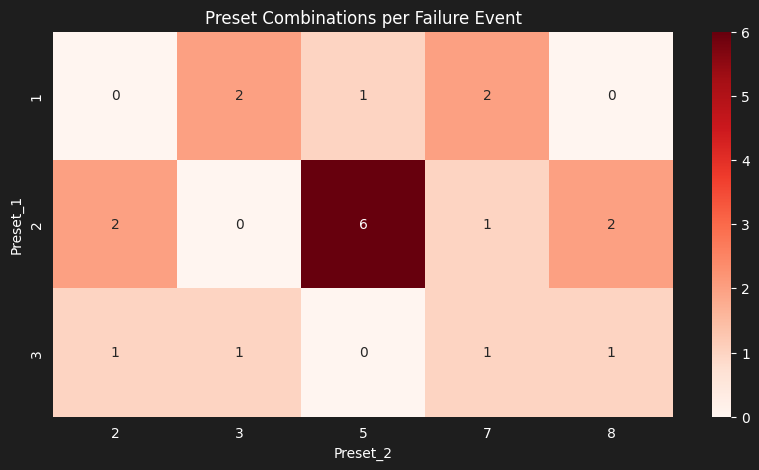

In [57]:
# Heatmap plotting preset combinations on operation cycles before failure events
fig, ax = plt.subplots(figsize=(10, 5))

combo_heatmap = presets_pre_failure.groupby(['Preset_1','Preset_2']).size().unstack(fill_value=0)

sns.heatmap(combo_heatmap, annot=True, cmap='Reds', fmt='d')
plt.title('Preset Combinations per Failure Event')
plt.show()

- Preset_2=5 appears to be a high-risk precursor. It's the most common setting used in the cycles immediately before failures occur;

- When Preset_1=2 is used (especially with Preset_2=5), it strongly correlates with impending failure

### Key Findings of Section 3.1.5: Pre-failure event analysis

**Early Warning Signals:**
- Nearly all 10 failures showed sensor changes 2-3 cycles before failing
- Two distinct failure patterns were identified

**Temperature Failures (Events 2, 4, 10):**
- Sudden temperature spikes before failure
- **Monitor**: Set alerts for temperature volatility

**Pressure/Vibration Failures (Events 1, 3, 5, 6, 7, 8, 9):**
- Gradual pressure and vibration increases
- **Monitor**: Track trends over multiple cycles  

**High-Risk Configuration:**
- **(Preset_1=2, Preset_2=5)**: Used before 6 failures - highest risk combination
- **Preset_1=2**: High predominance, risky configuration